# Gaussian Mixture Model - Instacart (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    gmm_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/instacart_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 3


,recency,frequency,avg_basket_size
0,-0.286895,-0.070348,-0.578158
1,1.212334,0.316791,0.820566
2,-0.568000,0.138171,-0.236083
3,1.212334,-0.826933,-1.313020
4,-1.036509,-1.054508,0.139108


## Evaluación del número de clusters


In [3]:
resultados_gmm = gmm_metrics(X)
display(resultados_gmm)

,k,silhouette,calinski_harabasz,davies_bouldin,bic,aic,tiempo_segundos
0,2,0.256181,69420.079615,1.381141,941518.305397,941385.229005,2.165774
1,3,0.157116,57161.435280,2.332519,897723.410146,897518.677237,1.365617
2,4,0.162991,57782.519531,1.518937,890377.390262,890101.000834,1.500031
3,5,0.147932,56798.279843,3.745328,886222.640832,885874.594885,1.254646
4,6,0.165020,52554.601138,4.228767,871533.961125,871114.258660,1.228689
5,7,0.112344,43418.073961,3.949242,859607.740480,859116.381496,2.231615
6,8,0.129245,46435.299344,3.798379,870659.068207,870096.052704,1.958678
7,9,0.107515,45957.172217,1.599628,868580.380849,867945.708828,3.053062
8,10,0.124142,38229.004898,6.380328,835279.198979,834572.870440,2.407559


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_gmm,
    model_name="gmm",
    dataset_name="instacart",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

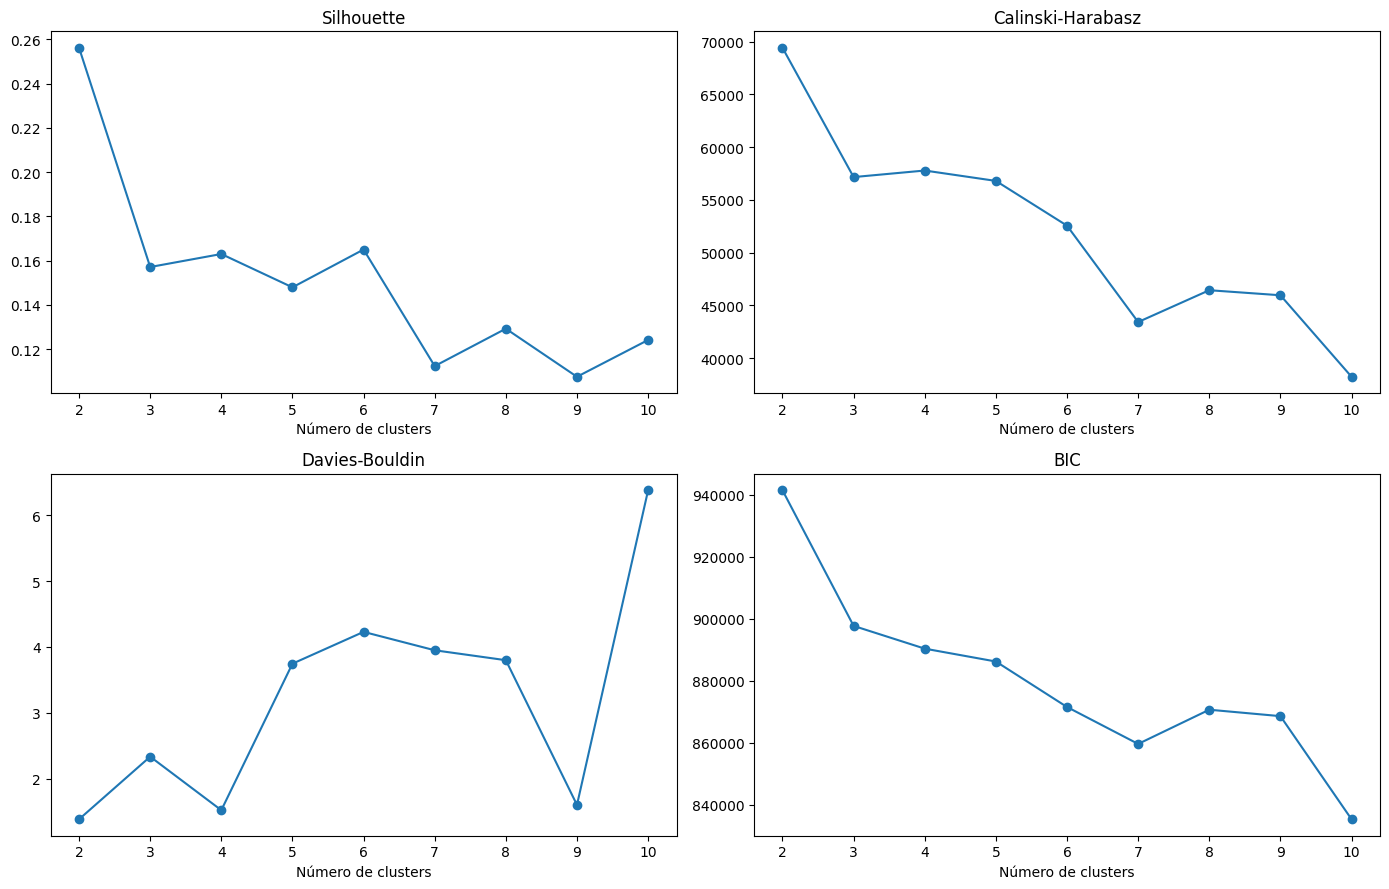

In [4]:
plot_clustering_metrics(
    resultados_gmm,
    fourth_metric="bic",
    fourth_title="BIC",
)

## Ajuste final y perfil de los clusters


In [ ]:
modelo, labels = fit_clustering_model(
    model_name="gmm",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0     63186
1    143023
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    30.64
1    69.36
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,30.000,8.516,9.535
1,11.346,18.716,10.136


- Cluster 0 - Clientes inactivos u ocasionales (30,64%): alcanzan la recencia máxima observada, realizan pocos pedidos y forman cestas ligeramente menores.
- Cluster 1 - Clientes activos y recurrentes (69,36%): compran mucho más recientemente, duplican ampliamente la frecuencia y mantienen cestas algo mayores.